# Implementing ANNs with TensorFlow - Homework 05 (Group 4)

## Assignment: CIFAR-10 Classification

### Preparing the data set

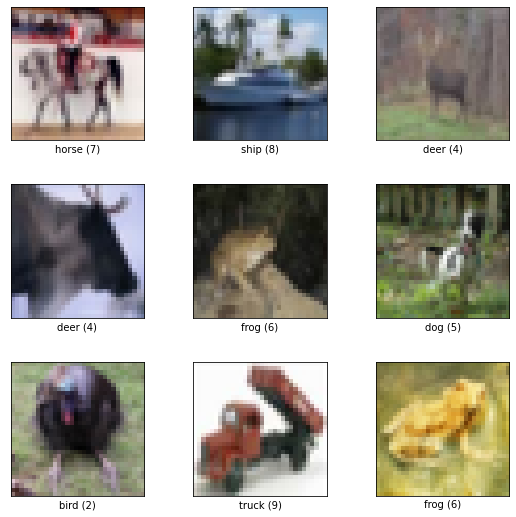

In [48]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

# load the data
(train_ds, test_ds), ds_info = tfds.load("cifar10", split=["train", "test"], as_supervised=True, with_info=True)
# inspect the data: images of shape (32, 32, 3) representing ten non-overlapping classes
tfds.show_examples(train_ds, ds_info)
# take only a subset of the data to speed up the training process
train_ds = train_ds.take(5000)
test_ds = test_ds.take(500)

In [49]:
def prepare_data(cifar_10, batch_size=32):
  """
  This function is used to prepare the raw data for training and testing.

  Arguments:
  cifar_10 -- (a subset of) the CIFAR-10 dataset
  batch_size -- denotes the batch size (default is 32)
  """
  # convert images to float32 data type
  cifar_10 = cifar_10.map(lambda img, target: (tf.cast(img, tf.float32), target))
  # normalize the data by projecting the pixel values into range [-1, 1]
  cifar_10 = cifar_10.map(lambda img, target: (tf.cast(tf.image.per_image_standardization(img), tf.float32), target))
  # represent targets as one-hot vectors (depth=10 as there are ten possible classifications)
  cifar_10 = cifar_10.map(lambda img, target: (img, tf.one_hot(target, depth=10)))

  # cache progress into memory
  cifar_10 = cifar_10.cache()
  # shuffle the data into a random order
  cifar_10 = cifar_10.shuffle(1000)
  # use batches of a given size
  cifar_10 = cifar_10.batch(batch_size)
  # prefetch some data points
  cifar_10 = cifar_10.prefetch(tf.data.AUTOTUNE)

  return cifar_10

# transform the training and test data
train_dataset = train_ds.apply(prepare_data)
test_dataset = test_ds.apply(prepare_data)

### The CNN model

In [50]:
class ConvModel(tf.keras.Model):
  """
  This subclass of the keras model builds our neural network.
  """
  def __init__ (self, layer_config, optimizer):
    """
    The constructor initiates the layers and their activation functions.

    Arguments:
    layer_config -- a list of convolutional and pooling layers
    optimizer -- denotes the model optimizer
    """
    # call the parent constructor
    super().__init__()
    # use categorical crossentropy loss since the data holds more than two classes
    self.loss_function = tf.keras.losses.CategoricalCrossentropy()
    # use Adam as our optimizer
    self.optimizer = optimizer
    # instantiate the layers according to a given architecture
    self.conv_layers = layer_config
    # instantiate the output layer with softmax as activation function
    self.output_layer = tf.keras.layers.Dense(10, activation=tf.nn.softmax)
    # instantiate metric objects to keep track of the training/test loss and accuracy
    self.loss_metric = tf.keras.metrics.Mean(name="loss") 
    self.accuracy_metric = tf.keras.metrics.CategoricalAccuracy(name="accuracy")

  @tf.function
  def call (self, input):
    """
    This function calls the model on new input and returns the output as tensors.

    Arguments:
    input -- denotes the input tensors
    """
    # feed the input through the network
    output = self.conv_layers[0](input)
    for layer in self.conv_layers[1:]:
      output = layer(output)
    output = self.output_layer(output)

    return output

  def reset_metrics(self):
    """
    This function will reset the metric objects after every training epoch.
    """
    self.loss_metric.reset_states()
    self.accuracy_metric.reset_states()

  @tf.function
  def train_step(self, input):
    """
    This function defines a step during the training process
    Updates and returns the loss and accuracy metrics after the training step.

    Arguments:
    input -- the input tensors (img, target) to the model
    """
    img, target = input
    with tf.GradientTape() as tape:
      # create the prediction
      prediction = self(img, training=True)
      # calculate the loss with an additional regularization term
      loss = self.loss_function(target, prediction) + tf.reduce_sum(self.losses)
    # calculate the gradients
    gradients = tape.gradient(loss, model.trainable_variables)
    # apply the gradients
    self.optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    # update the metrics
    self.loss_metric.update_state(loss)
    self.accuracy_metric.update_state(target, prediction)

    #return {metric.name: metric.result() for metric in self.metrics}
    return self.loss_metric.result(), self.accuracy_metric.result()

  @tf.function
  def test(self, test_data):
    """
    A function to test how the model performs on the given data.
    Returns the loss and accuracy metrics.

    Arguments:
    test_data -- the data used for testing
    """
    # unpack the the test data
    img, target = test_data
    # create prediction but do not backpropagate
    prediction = self(img, training=False)
    # calculate loss
    loss = self.loss_function(target, prediction) + tf.reduce_sum(self.losses) 
    # update the metrics
    self.loss_metric.update_state(loss)
    self.accuracy_metric.update_state(target, prediction)

    #return {metric.name: metric.result() for metric in self.metrics}
    return self.loss_metric.result(), self.accuracy_metric.result()

### Training the network

In [52]:
def training(model, n_epochs):
  """
  Defines the training process of our neural network.
  Returns the training losses and accuracies.

  Arguments:
  model -- the model object representing our neural network
  n_epochs -- the number of training steps
  """
  # lists to track training/test losses and accuracies
  train_losses = []
  train_accuracies = []
  test_losses = []
  test_accuracies = []

  print("Training progress: \n")

  # train for given number of epochs
  for epoch in range(n_epochs):
    # train the network
    for data in train_dataset:
      train_loss, train_accuracy = model.train_step(data)
    # store training loss and accuracy
    train_losses.append(train_loss.numpy())
    train_accuracies.append(train_accuracy.numpy())

    # reset the model metrics
    model.reset_metrics()

    # test the network
    for data in test_dataset:
      test_loss, test_accuracy = model.test(data)
    # store test loss and accuracy
    test_losses.append(test_loss.numpy())
    test_accuracies.append(test_accuracy.numpy())

    # print the accuracy after the current epoch
    print(f'Epoch {str(epoch)} ended with accuracy {test_accuracies[-1]}')

    # again reset the model metrics
    model.reset_metrics()

  return train_losses, train_accuracies, test_losses, test_accuracies

In [53]:
tf.keras.backend.clear_session()
# hyperparameters for the training process
# train for 15 epochs
num_epochs = 15
# base model (taken from lecture material)
layers = [tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu"), 
          tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu"),
          tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
          tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu"),
          tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu"),
          tf.keras.layers.GlobalAvgPool2D()]
# use Adam optimizer
optimizer = tf.keras.optimizers.Adam()
# instantiate the model
model = ConvModel(layer_config=layers, optimizer=optimizer)
# train the base model
train_losses, train_accuracies, test_losses, test_accuracies = training(model, num_epochs)

Epoch: 0 ended with accuracy 0.23199999332427979
Epoch: 1 ended with accuracy 0.328000009059906
Epoch: 2 ended with accuracy 0.34599998593330383
Epoch: 3 ended with accuracy 0.37400001287460327
Epoch: 4 ended with accuracy 0.37599998712539673
Epoch: 5 ended with accuracy 0.42399999499320984
Epoch: 6 ended with accuracy 0.4099999964237213
Epoch: 7 ended with accuracy 0.4399999976158142
Epoch: 8 ended with accuracy 0.44600000977516174
Epoch: 9 ended with accuracy 0.47600001096725464
Epoch: 10 ended with accuracy 0.4580000042915344
Epoch: 11 ended with accuracy 0.49799999594688416
Epoch: 12 ended with accuracy 0.49799999594688416
Epoch: 13 ended with accuracy 0.5019999742507935
Epoch: 14 ended with accuracy 0.5120000243186951


### Visualization

In [54]:
def visualization(train_losses, train_accuracies, test_losses, test_accuracies):
  """
  This function visualizes the training progress by showing the mean losses and accuracies after each epoch.

  Arguments:
  train_losses -- denotes the recorded losses during training
  train_accuracies -- accuracies during training
  test_losses -- losses during the test stage
  test_accuracies -- accuracies during testing
  """
  # create the plot grid
  fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(9,6))
  # plot training and test losses and accuracies
  line1, = axes[0].plot(train_losses, color="orange")
  line2, = axes[0].plot(test_losses, color="green")
  line3, = axes[1].plot(train_accuracies, color="orange")
  line4, = axes[1].plot(test_accuracies, color="green")
  # set the axis limits and labels
  axes[0].set(ylabel="Loss")
  axes[1].set(ylim=[0, 1], xlabel="Training steps", ylabel="Accuracy")
  # create the legend
  axes[0].legend((line1, line2), ("Training","Test"))

  fig.suptitle("Training Progress")

  plt.show()

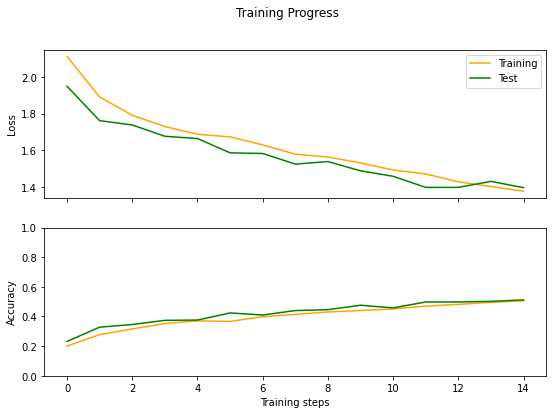

In [55]:
visualization(train_losses, train_accuracies, test_losses, test_accuracies)

**Remark:**

We can see that the base model performs relatively poor on both the training and test data, approaching only an accuracy of circa 50%.

### Adjusting hyperparameters and architecture

#### Variation 1:

**Remark:**

#### Variation 2:

**Remark:**

#### Variation 3:

**Remark:**